# Finance project

__Data Descirption:__ the file Bank.xls contains data on 5000 customers.The data include customer demographic Information (age,income, etc), the customers's relationship with bank (mortgage, securities, acoount etc) and the
customer response to the last personal loan campaign(personal loan). Among these 5000 customers only 480=(9.6%) accepted the personal loan that was offered them in the earlier campaign.

__Context:__ This case is about a bank(Thera Bank) whose management wants to explore ways of converting its liability customers to personal loan customers(while retaining them as despositors). A campaign that the bank ran last year for liability customers showed a healthy coversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio with minimal budget.

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [121]:
pip install pandas openpyxl --quiet

Note: you may need to restart the kernel to use updated packages.


In [7]:
#file_path= "D:/Financial Data Analysis project.csv"

In [8]:
df= pd.read_excel("Bank_Personal_Loan_Modelling.xlsx", 1)
df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [9]:
df.shape

(5000, 14)

In [10]:
df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [11]:
df.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [12]:
df.drop(["ID", "ZIP Code"], axis=1, inplace=True)

In [127]:
df.columns

Index(['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education',
       'Mortgage', 'Personal Loan', 'Securities Account', 'CD Account',
       'Online', 'CreditCard'],
      dtype='object')

In [14]:
# import plotly
import plotly.express as ps

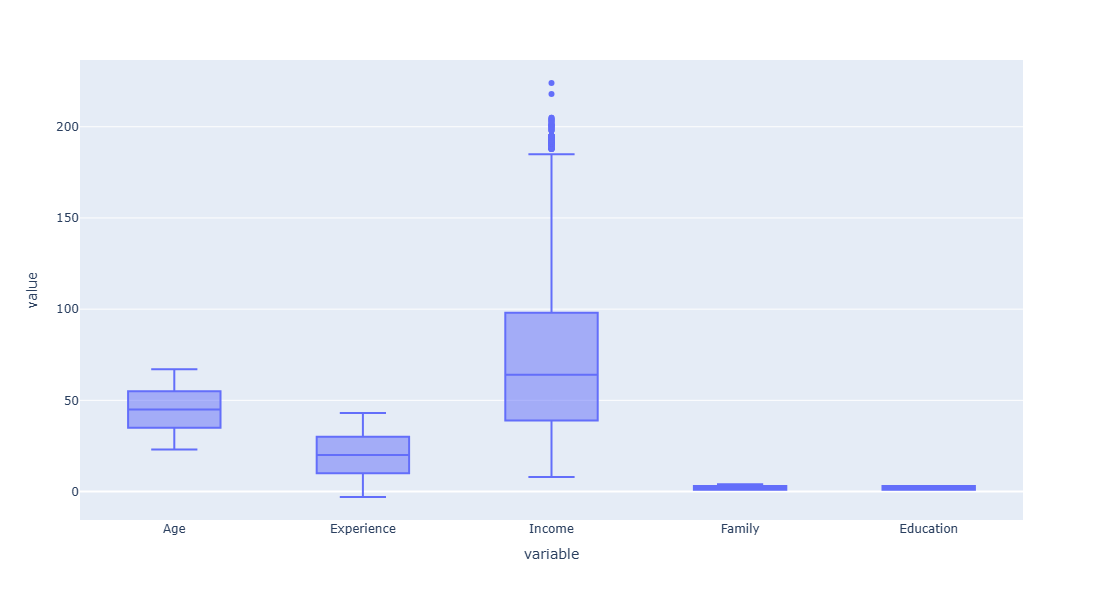

In [120]:
# 5 Number summary
fig= ps.box(df, y=["Age","Experience", "Income", "Family", "Education"], width=800, height=600)
fig.show()

In [16]:
df.dtypes

Age                     int64
Experience              int64
Income                  int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage                int64
Personal Loan           int64
Securities Account      int64
CD Account              int64
Online                  int64
CreditCard              int64
dtype: object

In [17]:
df.skew()

Age                  -0.029341
Experience           -0.026325
Income                0.841339
Family                0.155221
CCAvg                 1.598457
Education             0.227093
Mortgage              2.104002
Personal Loan         2.743607
Securities Account    2.588268
CD Account            3.691714
Online               -0.394785
CreditCard            0.904589
dtype: float64

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Experience'}>,
        <Axes: title={'center': 'Income'}>],
       [<Axes: title={'center': 'Family'}>,
        <Axes: title={'center': 'CCAvg'}>,
        <Axes: title={'center': 'Education'}>],
       [<Axes: title={'center': 'Mortgage'}>,
        <Axes: title={'center': 'Personal Loan'}>,
        <Axes: title={'center': 'Securities Account'}>],
       [<Axes: title={'center': 'CD Account'}>,
        <Axes: title={'center': 'Online'}>,
        <Axes: title={'center': 'CreditCard'}>]], dtype=object)

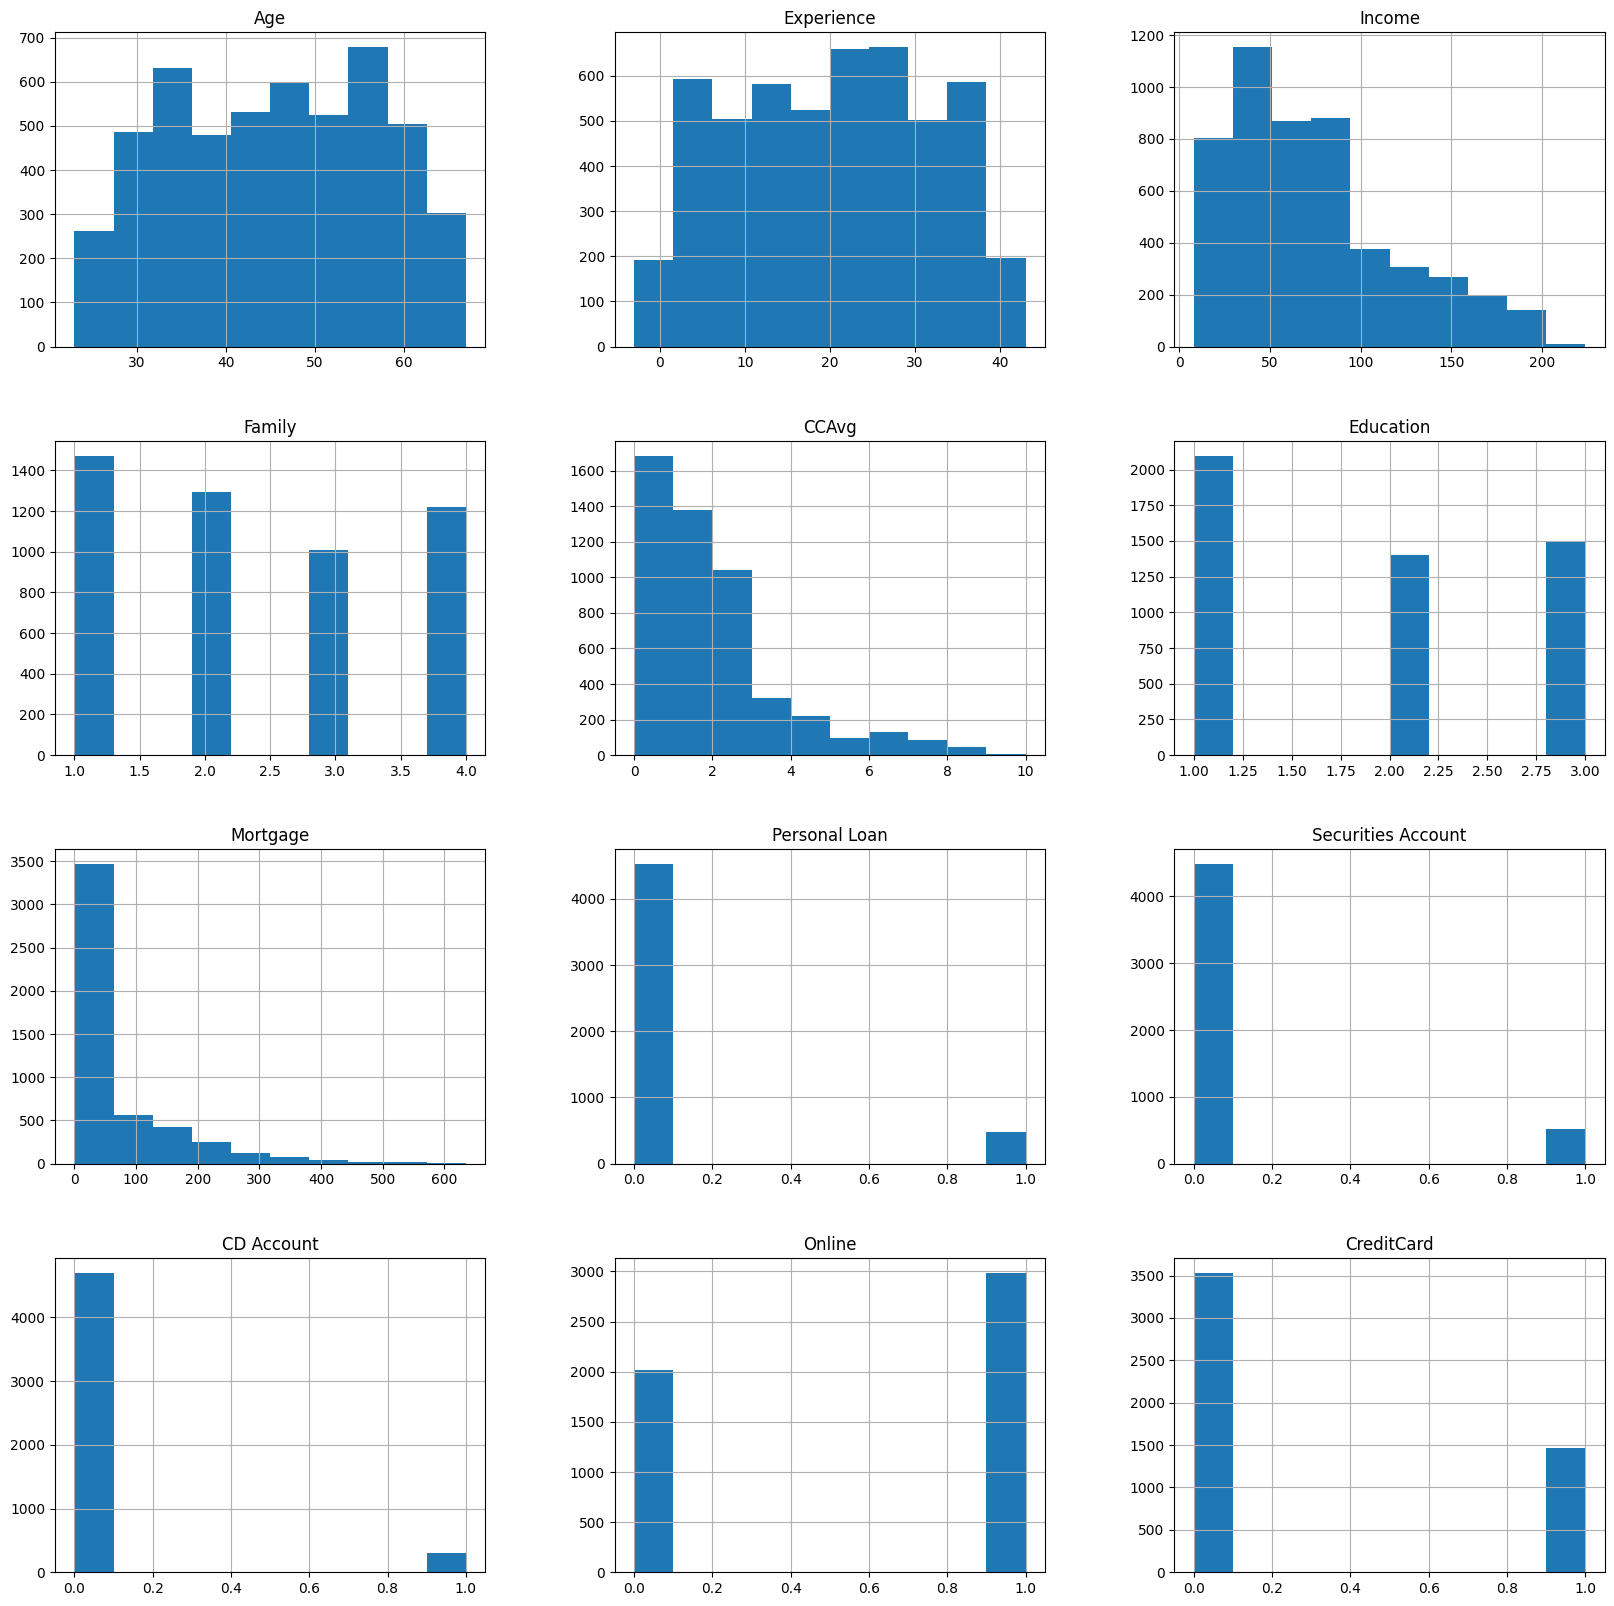

In [18]:
df.hist(figsize= (20,20))

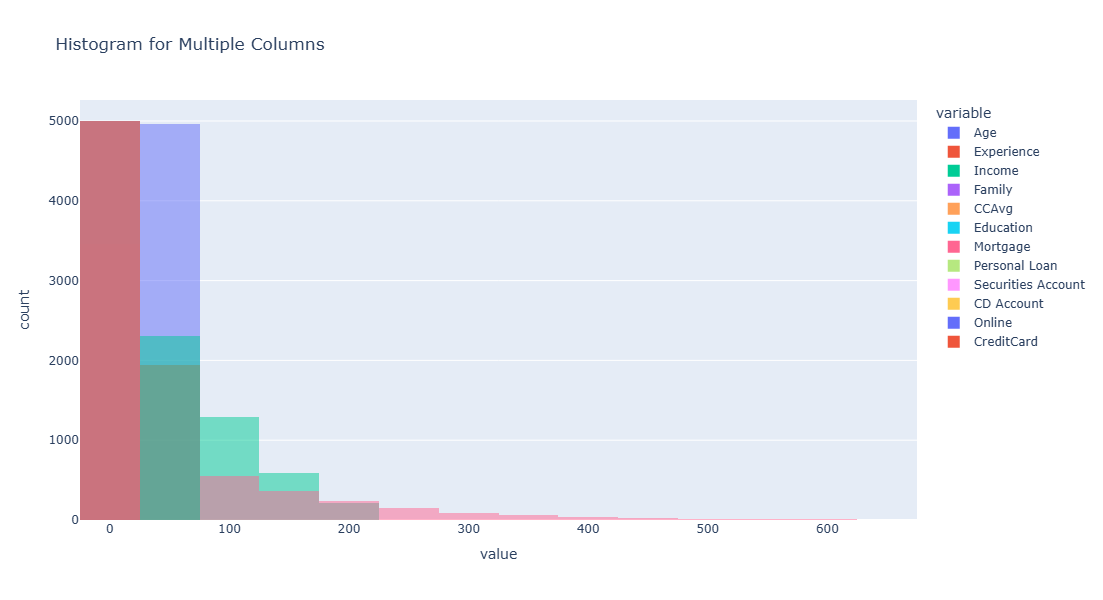

In [128]:
import plotly.express as px
import pandas as pd

# Create histogram for multiple columns
fig = px.histogram(df, 
                   x=df.columns, nbins=18,
                   title="Histogram for Multiple Columns",
                   barmode="overlay", width=800, height=600)  # Overlay bars to show them together
fig.show()


C:\Users\zh582\AppData\Local\Temp\ipykernel_20888\1298335821.py:3: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='Experience', ylabel='Density'>

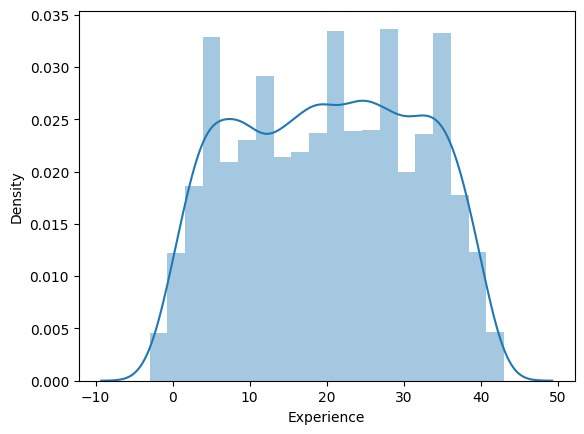

In [20]:
import seaborn as sns

sns.distplot(df["Experience"])

In [21]:
# we check negative values in experience
negative_exp= df[df["Experience"]<0]
negative_exp

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
89,25,-1,113,4,2.300000,3,0,0,0,0,0,1
226,24,-1,39,2,1.700000,2,0,0,0,0,0,0
315,24,-2,51,3,0.300000,3,0,0,0,0,1,0
451,28,-2,48,2,1.750000,3,89,0,0,0,1,0
524,24,-1,75,4,0.200000,1,0,0,0,0,1,0
536,25,-1,43,3,2.400000,2,176,0,0,0,1,0
540,25,-1,109,4,2.300000,3,314,0,0,0,1,0
576,25,-1,48,3,0.300000,3,0,0,0,0,0,1
583,24,-1,38,2,1.700000,2,0,0,0,0,1,0
597,24,-2,125,2,7.200000,1,0,0,1,0,0,1


In [22]:
negative_exp.shape

(52, 12)

C:\Users\zh582\AppData\Local\Temp\ipykernel_20888\2132290437.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='Age', ylabel='Density'>

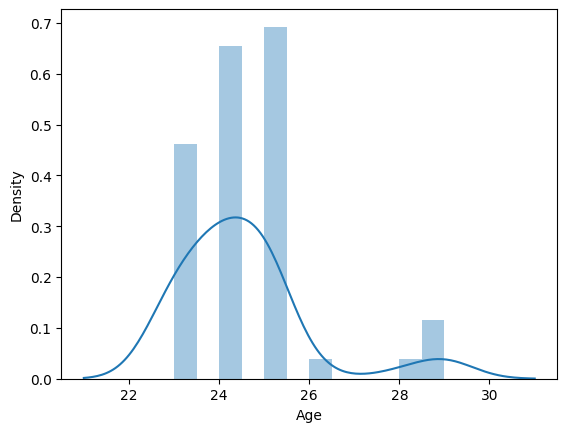

In [129]:
sns.distplot(negative_exp["Age"])

In [24]:
# we check mean
negative_exp["Experience"].mean()

np.float64(-1.4423076923076923)

In [25]:
# we check size
negative_exp.size

624

In [26]:
print("There are {} records which has negative values for experience, approx {} %".format(negative_exp.size,
     ((negative_exp.size/df.size)*100)))

There are 624 records which has negative values for experience, approx 1.04 %


In [27]:
# we copy data 
data=df.copy()
data.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1


In [28]:
import numpy as np

In [29]:
# we ssign mean (filling with mean) where negative values
# here first less 0 means negative then mean of experience than fill
data["Experience"]=np.where(data["Experience"]<0,
                           data["Experience"].mean(),
                            data["Experience"])

In [30]:
# if we check if still negative data is there
data[data["Experience"]<0]

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard


In [31]:
data.corr()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
Age,1.000000,0.977008,-0.055269,-0.046418,-0.052030,0.041334,-0.012539,-0.007726,-0.000436,0.008043,0.013702,0.007681
Experience,0.977008,1.000000,-0.049054,-0.045488,-0.048719,0.018097,-0.013378,-0.014045,-0.000462,0.005502,0.013455,0.008833
Income,-0.055269,-0.049054,1.000000,-0.157501,0.645993,-0.187524,0.206806,0.502462,-0.002616,0.169738,0.014206,-0.002385
Family,-0.046418,-0.045488,-0.157501,1.000000,-0.109285,0.064929,-0.020445,0.061367,0.019994,0.014110,0.010354,0.011588
CCAvg,-0.052030,-0.048719,0.645993,-0.109285,1.000000,-0.136138,0.109909,0.366891,0.015087,0.136537,-0.003620,-0.006686
Education,0.041334,0.018097,-0.187524,0.064929,-0.136138,1.000000,-0.033327,0.136722,-0.010812,0.013934,-0.015004,-0.011014
Mortgage,-0.012539,-0.013378,0.206806,-0.020445,0.109909,-0.033327,1.000000,0.142095,-0.005411,0.089311,-0.005995,-0.007231
Personal Loan,-0.007726,-0.014045,0.502462,0.061367,0.366891,0.136722,0.142095,1.000000,0.021954,0.316355,0.006278,0.002802
Securities Account,-0.000436,-0.000462,-0.002616,0.019994,0.015087,-0.010812,-0.005411,0.021954,1.000000,0.317034,0.012627,-0.015028
CD Account,0.008043,0.005502,0.169738,0.014110,0.136537,0.013934,0.089311,0.316355,0.317034,1.000000,0.175880,0.278644


<Axes: >

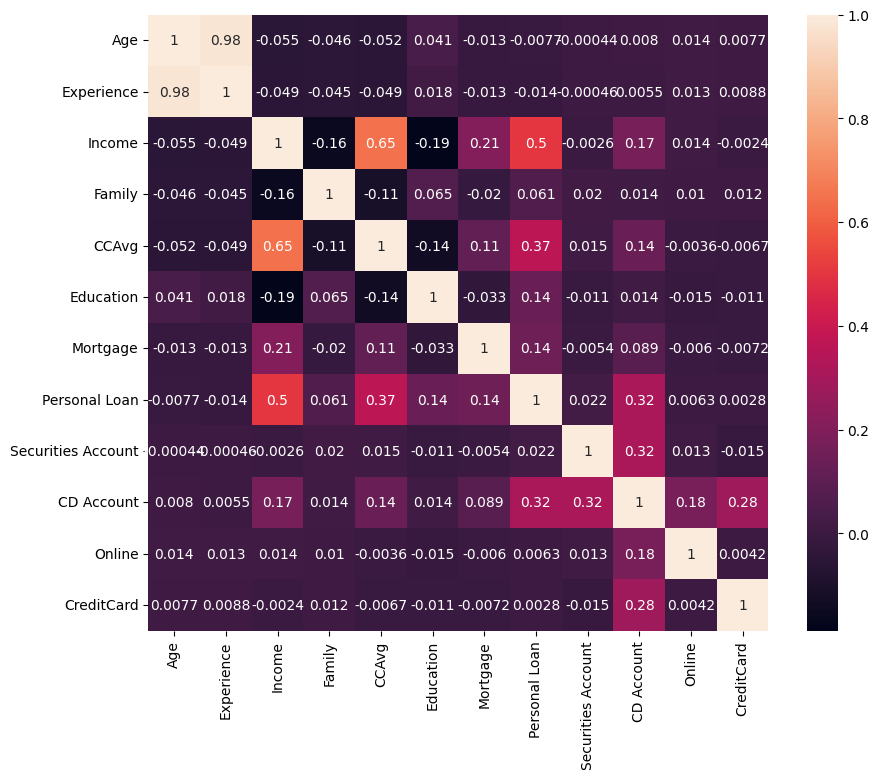

In [32]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True)

In [33]:
data= data.drop(["Experience"], axis=1)

In [34]:
data.head()

,Age,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,49,4,1.6,1,0,0,1,0,0,0
1,45,34,3,1.5,1,0,0,1,0,0,0
2,39,11,1,1.0,1,0,0,0,0,0,0
3,35,100,1,2.7,2,0,0,0,0,0,0
4,35,45,4,1.0,2,0,0,0,0,0,1


In [35]:
# education
data["Education"].unique()


array([1, 2, 3])

In [36]:
# we convert this in categorical means(readable format)
def experience (x):
    if x==1:
        return "Undergraduate"
    if x==2:
        return "Graduate"
    if x==3:
        return "Professional Person"

In [37]:
# we apply this defined function EDU column
data["EDU"]= data["Education"].apply(experience)

In [38]:
data.head()

,Age,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,EDU
0,25,49,4,1.6,1,0,0,1,0,0,0,Undergraduate
1,45,34,3,1.5,1,0,0,1,0,0,0,Undergraduate
2,39,11,1,1.0,1,0,0,0,0,0,0,Undergraduate
3,35,100,1,2.7,2,0,0,0,0,0,0,Graduate
4,35,45,4,1.0,2,0,0,0,0,0,1,Graduate


In [39]:
data["EDU"].unique()

array(['Undergraduate', 'Graduate', 'Professional Person'], dtype=object)

In [40]:
# we groupby and count 
education_dis= data.groupby("EDU")["Age"].count()
education_dis

EDU
Graduate               1403
Professional Person    1501
Undergraduate          2096
Name: Age, dtype: int64

In [41]:
fig=px.pie(data, values= education_dis, names=education_dis.index, title= "Pie Chart", width=600, height=600)
fig.show()

In [42]:
data.columns

Index(['Age', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage',
       'Personal Loan', 'Securities Account', 'CD Account', 'Online',
       'CreditCard', 'EDU'],
      dtype='object')

In [43]:
data["Income"].unique()

array([ 49,  34,  11, 100,  45,  29,  72,  22,  81, 180, 105, 114,  40,
       112, 130, 193,  21,  25,  63,  62,  43, 152,  83, 158,  48, 119,
        35,  41,  18,  50, 121,  71, 141,  80,  84,  60, 132, 104,  52,
       194,   8, 131, 190,  44, 139,  93, 188,  39, 125,  32,  20, 115,
        69,  85, 135,  12, 133,  19,  82, 109,  42,  78,  51, 113, 118,
        64, 161,  94,  15,  74,  30,  38,   9,  92,  61,  73,  70, 149,
        98, 128,  31,  58,  54, 124, 163,  24,  79, 134,  23,  13, 138,
       171, 168,  65,  10, 148, 159, 169, 144, 165,  59,  68,  91, 172,
        55, 155,  53,  89,  28,  75, 170, 120,  99, 111,  33, 129, 122,
       150, 195, 110, 101, 191, 140, 153, 173, 174,  90, 179, 145, 200,
       183, 182,  88, 160, 205, 164,  14, 175, 103, 108, 185, 204, 154,
       102, 192, 202, 162, 142,  95, 184, 181, 143, 123, 178, 198, 201,
       203, 189, 151, 199, 224, 218])

In [44]:
data["Securities Account"].value_counts()

Securities Account
0    4478
1     522
Name: count, dtype: int64

In [45]:
data["CD Account"].value_counts()

CD Account
0    4698
1     302
Name: count, dtype: int64

In [46]:
def security (y):
    if (y["Securities Account"]==1) & (y["CD Account"]==1):
        return "Holds Securities & Deposit"
    if (y["Securities Account"]==0) & (y["CD Account"]==0):
        return "Does not hold Securities & Deposit account"
    if (y["Securities Account"]==1) & (y["CD Account"]==0):
        return "Holds Securities account"
    if (y["Securities Account"]==0) & (y["CD Account"]==1):
        return "Holds only deposit account"

In [47]:
# we create a column and we put this in that column
data["Account_holder_category"]= data.apply(security, axis=1)

In [48]:
data.head()

,Age,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,EDU,Account_holder_category
0,25,49,4,1.6,1,0,0,1,0,0,0,Undergraduate,Holds Securities account
1,45,34,3,1.5,1,0,0,1,0,0,0,Undergraduate,Holds Securities account
2,39,11,1,1.0,1,0,0,0,0,0,0,Undergraduate,Does not hold Securities & Deposit account
3,35,100,1,2.7,2,0,0,0,0,0,0,Graduate,Does not hold Securities & Deposit account
4,35,45,4,1.0,2,0,0,0,0,0,1,Graduate,Does not hold Securities & Deposit account


In [116]:
values= data["Account_holder_category"].value_counts().values
values

array([4323,  375,  155,  147])

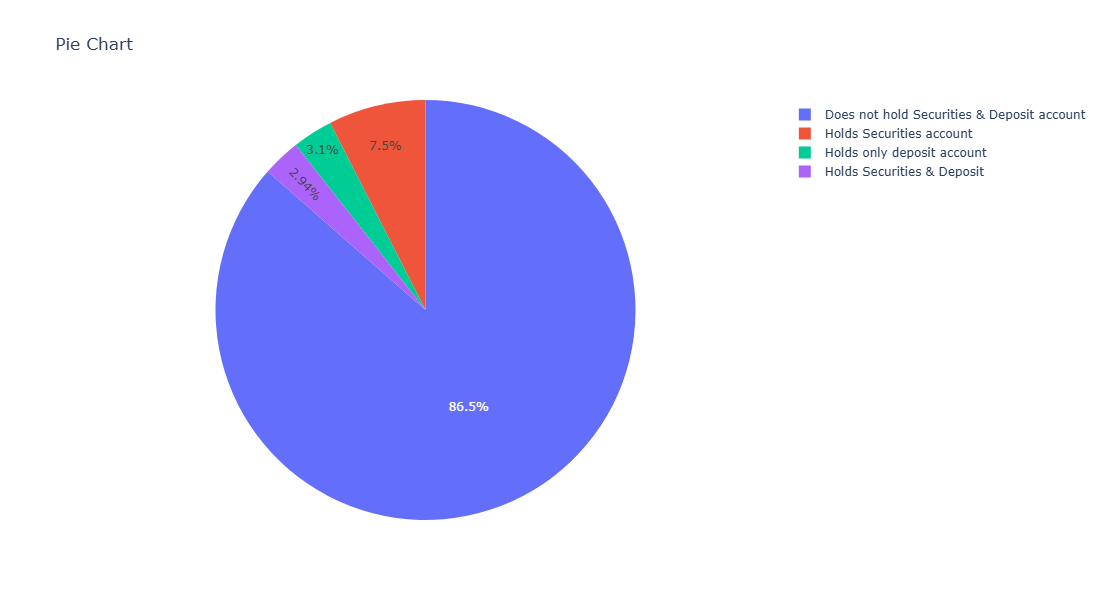

In [138]:
fig=px.pie(data, values=data["Account_holder_category"].value_counts().values,  # Counts of each category
    names=data["Account_holder_category"].value_counts().index, title="Pie Chart", width=800, height=600)
fig.show()

In [90]:
#values = data.groupby('Account_holder_category').size().reset_index()
#values.index

In [ ]:
data.columns

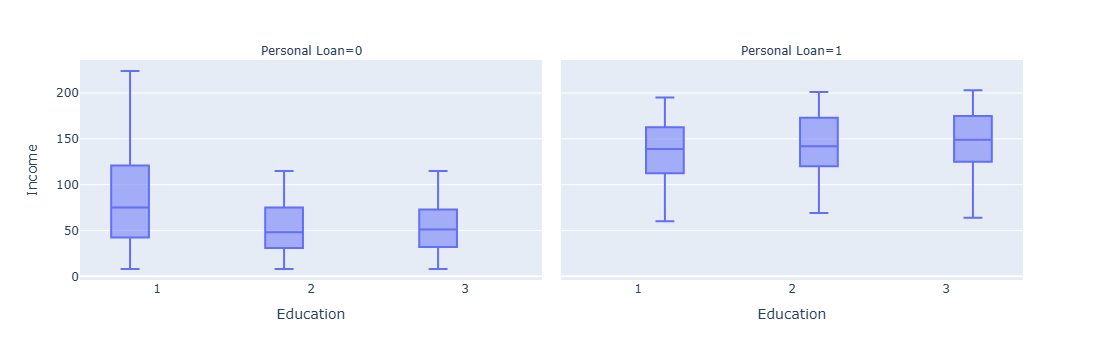

In [126]:
# now take mutilplt columns
# here face_col is like hue
ps.box(data, x="Education", y="Income", facet_col= "Personal Loan")

In [125]:
data.columns

Index(['Age', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage',
       'Personal Loan', 'Securities Account', 'CD Account', 'Online',
       'CreditCard', 'EDU', 'Account_holder_category'],
      dtype='object')

C:\Users\zh582\AppData\Local\Temp\ipykernel_20888\2690042381.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\zh582\AppData\Local\Temp\ipykernel_20888\2690042381.py:4: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




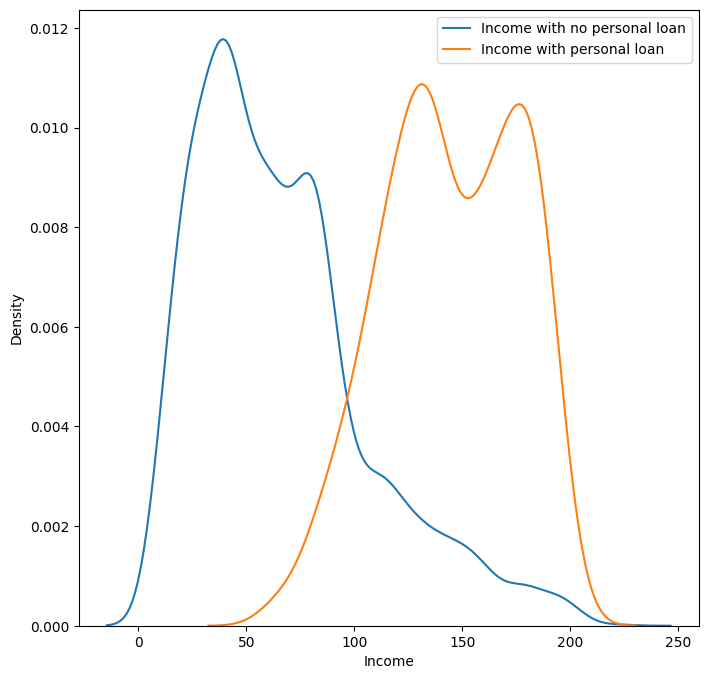

In [130]:
plt.figure(figsize=(8,8))
sns.distplot(data[data["Personal Loan"]== 0]["Income"], hist=False, 
            label="Income with no personal loan")
sns.distplot(data[data["Personal Loan"]== 1]["Income"], hist=False,
            label="Income with personal loan")
plt.legend()

In [132]:
def plot(col1, col2, label1, label2, title):
    sns.distplot(data[data[col2]==0][col1], hist=False,
            label=label1)
    sns.distplot(data[data[col2]==1][col1], hist=False,
            label=label2)
    plt.legend()
    plt.title(title)

C:\Users\zh582\AppData\Local\Temp\ipykernel_20888\447288944.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\zh582\AppData\Local\Temp\ipykernel_20888\447288944.py:4: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




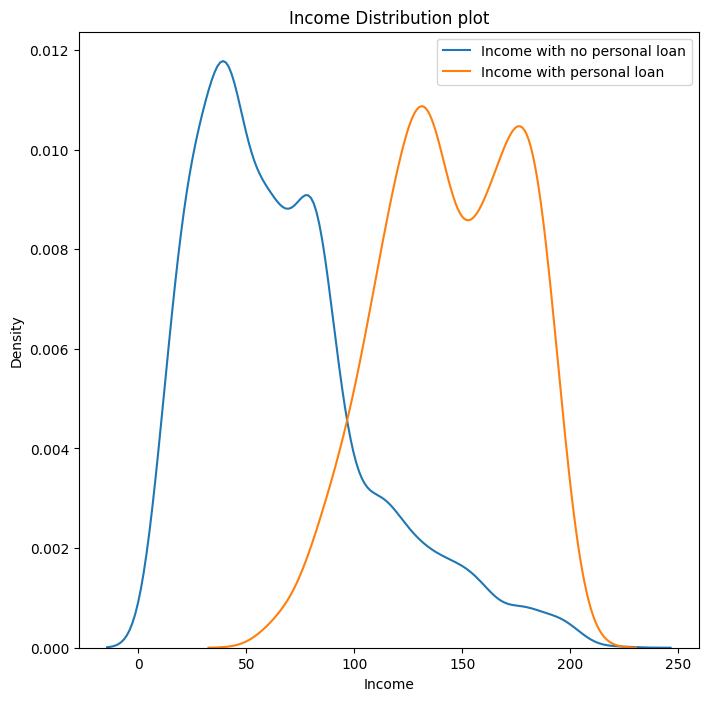

In [135]:
plt.figure(figsize=(8,8))
plot("Income", "Personal Loan", "Income with no personal loan", "Income with personal loan", "Income Distribution plot")

C:\Users\zh582\AppData\Local\Temp\ipykernel_20888\447288944.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\zh582\AppData\Local\Temp\ipykernel_20888\447288944.py:4: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




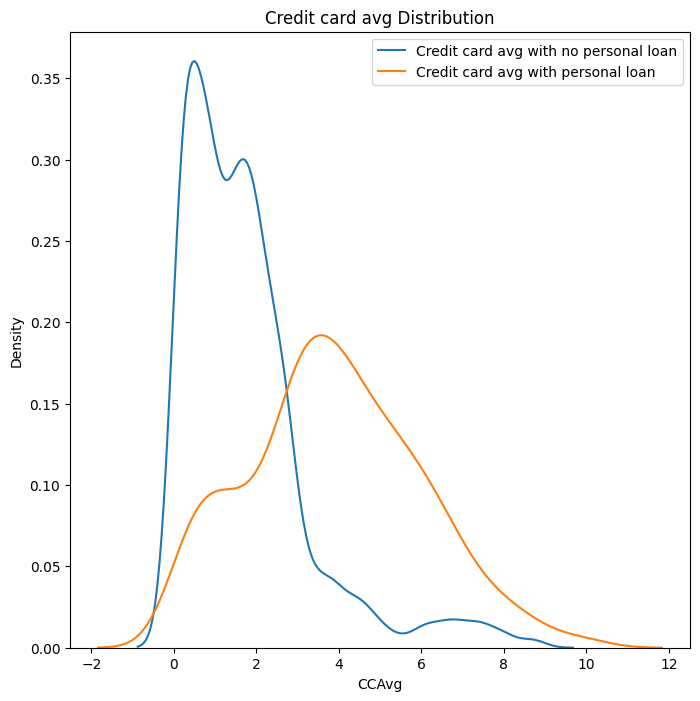

In [136]:
plt.figure(figsize=(8,8))
plot("CCAvg", "Personal Loan",
    "Credit card avg with no personal loan",
    "Credit card avg with personal loan",
    "Credit card avg Distribution")

In [ ]:
col= ["Securities Account",
     "Online",
     "Account_holder_category",
     "CreditCard"]

In [ ]:
for i in col:
    plt.figure(figsize=(10,8))
    sns.countplot(x=i, data=data, hue="Personal Loan")

In [61]:
# we handle skewness in data
from scipy.stats import zscore

In [62]:
import sys

if "scipy" in sys.modules:
    print("SciPy is already imported.")
else:
    print("SciPy is not imported yet.")

SciPy is already imported.


In [69]:
data.dtypes

Age                          int64
Income                       int64
Family                       int64
CCAvg                      float64
Education                    int64
Mortgage                     int64
Personal Loan                int64
Securities Account           int64
CD Account                   int64
Online                       int64
CreditCard                   int64
EDU                         object
Account_holder_category     object
dtype: object

In [72]:
# Select only numeric columns
numeric_data = data.select_dtypes(include='number')

# Calculate Q1, Q3, and IQR
q1 = numeric_data.quantile(0.25)
q3 = numeric_data.quantile(0.75)
IQR = q3 - q1

print("IQR:\n", IQR)


IQR:
 Age                    20.0
Income                 59.0
Family                  2.0
CCAvg                   1.8
Education               2.0
Mortgage              101.0
Personal Loan           0.0
Securities Account      0.0
CD Account              0.0
Online                  1.0
CreditCard              1.0
dtype: float64


In [54]:
# Log normal transformation
#The +1 prevents issues with taking the log of zero (logarithm of zero is undefined).
#The np.log() function applies the natural logarithm (base 𝑒) element-wise to the selected columns.

data_1= data[["Income", "CCAvg"]]
data_1= np.log(data_1+1)
data_1

,Income,CCAvg
0,3.912023,0.955511
1,3.555348,0.916291
2,2.484907,0.693147
3,4.615121,1.308333
4,3.828641,0.693147
...,...,...
4995,3.713572,1.064711
4996,2.772589,0.336472
4997,3.218876,0.262364
4998,3.912023,0.405465


In [55]:
# 2nd method
# power transformation (handling skewness)
from sklearn.preprocessing import PowerTransformer

C:\Users\zh582\AppData\Local\Temp\ipykernel_20888\2158593001.py:4: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




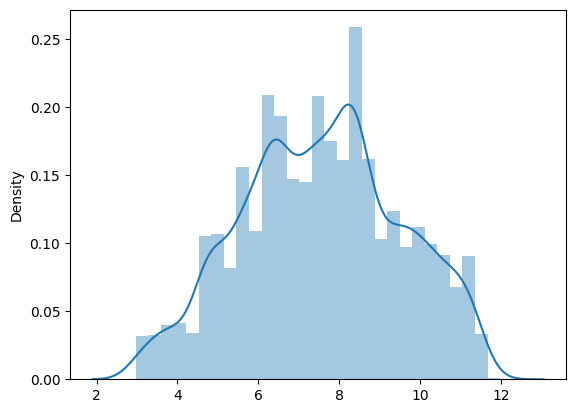

In [58]:
pt= PowerTransformer(method="yeo-johnson", standardize=False)
pt.fit(data["Income"].values.reshape(-1,1))
Income= pt.transform(data["Income"].values.reshape(-1,1))
sns.distplot(Income)
plt.show()

In [ ]:
# we can go further
- Handle Outliers
- Convert categorical into numerical
- Data fit
- Logistic, SVM